<a href="https://colab.research.google.com/github/AyushTronics/CNN/blob/main/lab_assignment(24it3015)_.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# Install
!pip install tensorflow numpy pandas matplotlib -q

# Imports
import tensorflow as tf
import numpy as np
import pandas as pd
import matplotlib
import random

# =========================
# Set Seeds (IMPORTANT)
# =========================
tf.random.set_seed(42)
np.random.seed(42)
random.seed(42)

# =========================
# Print Versions
# =========================
print("TensorFlow Version:", tf.__version__)
print("NumPy Version:", np.__version__)
print("Pandas Version:", pd.__version__)
print("Matplotlib Version:", matplotlib.__version__)

# =========================
# GPU Check
# =========================
gpus = tf.config.list_physical_devices('GPU')

if gpus:
    print("\n GPU is available")
    print("GPU Details:", gpus)
else:
    print("\n No GPU available")

# =========================
# Explanation
# =========================

print("\n--- EXPLANATION ---")
print("GPU uses thousands of cores for parallel processing, making deep learning much faster.")
print("CPU is slower because it processes operations sequentially with limited cores.")

print("\nSeeds Explanation:")
print("random.seed(42) -> controls Python randomness")
print("np.random.seed(42) -> controls NumPy randomness")
print("tf.random.set_seed(42) -> controls TensorFlow randomness")

TensorFlow Version: 2.19.0
NumPy Version: 2.0.2
Pandas Version: 2.2.2
Matplotlib Version: 3.10.0

 GPU is available
GPU Details: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]

--- EXPLANATION ---
GPU uses thousands of cores for parallel processing, making deep learning much faster.
CPU is slower because it processes operations sequentially with limited cores.

Seeds Explanation:
random.seed(42) -> controls Python randomness
np.random.seed(42) -> controls NumPy randomness
tf.random.set_seed(42) -> controls TensorFlow randomness


11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 13s 0us/step
MNIST Train Shape: (60000, 28, 28)
MNIST Test Shape: (10000, 28, 28)
CIFAR-10 Train Shape: (50000, 32, 32, 3)
CIFAR-10 Test Shape: (10000, 32, 32, 3)

MNIST dtype: uint8 Min: 0 Max: 255
CIFAR dtype: uint8 Min: 0 Max: 255

MNIST Class Distribution:
Class 0: 5923 samples
Class 1: 6742 samples
Class 2: 5958 samples
Class 3: 6131 samples
Class 4: 5842 samples
Class 5: 5421 samples
Class 6: 5918 samples
Class 7: 6265 samples
Class 8: 5851 samples
Class 9: 5949 samples


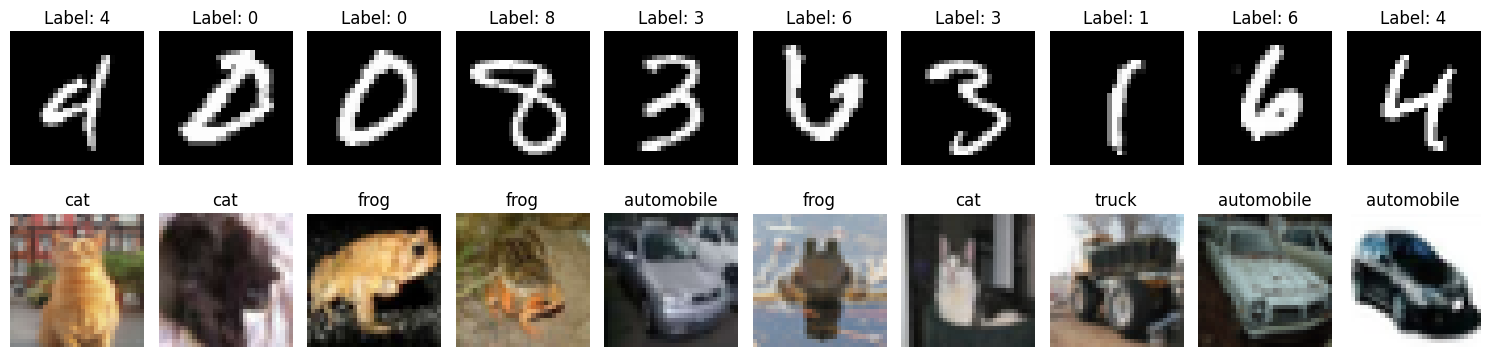

In [2]:
# Load datasets
from tensorflow.keras.datasets import mnist, cifar10
import numpy as np

(x_train_m, y_train_m), (x_test_m, y_test_m) = mnist.load_data()
(x_train_c, y_train_c), (x_test_c, y_test_c) = cifar10.load_data()

# (a) Shapes
print("MNIST Train Shape:", x_train_m.shape)
print("MNIST Test Shape:", x_test_m.shape)

print("CIFAR-10 Train Shape:", x_train_c.shape)
print("CIFAR-10 Test Shape:", x_test_c.shape)

# (b) Data type and range
print("\nMNIST dtype:", x_train_m.dtype, "Min:", x_train_m.min(), "Max:", x_train_m.max())
print("CIFAR dtype:", x_train_c.dtype, "Min:", x_train_c.min(), "Max:", x_train_c.max())

# (c) Class distribution (MNIST)
unique, counts = np.unique(y_train_m, return_counts=True)
print("\nMNIST Class Distribution:")
for u, c in zip(unique, counts):
    print(f"Class {u}: {c} samples")

import matplotlib.pyplot as plt

# CIFAR class names
cifar_classes = ['airplane','automobile','bird','cat','deer',
                 'dog','frog','horse','ship','truck']

plt.figure(figsize=(15,4))

# Top row → MNIST
for i in range(10):
    idx = np.random.randint(0, len(x_train_m))
    plt.subplot(2, 10, i+1)
    plt.imshow(x_train_m[idx], cmap='gray')
    plt.title(f"Label: {y_train_m[idx]}")
    plt.axis('off')

# Bottom row → CIFAR
for i in range(10):
    idx = np.random.randint(0, len(x_train_c))
    plt.subplot(2, 10, 10+i+1)
    plt.imshow(x_train_c[idx])
    plt.title(cifar_classes[y_train_c[idx][0]])
    plt.axis('off')

plt.tight_layout()
plt.savefig("dataset_samples.png")
plt.show()

A) shapes:
MNIST training set: (60000, 28, 28)
MNIST test set: (10000, 28, 28)

CIFAR-10 training set: (50000, 32, 32, 3)
CIFAR-10 test set: (10000, 32, 32, 3)

B) datatype is unit8 and pixel value range is from 0 to 255

C) Class Distribution:
   Each class in MNIST has approximately 6000 samples.
   The dataset is balanced since all classes have nearly equal number of samples.


In [3]:
from tensorflow.keras.utils import to_categorical
import numpy as np

def preprocess_data(x, y, is_mnist=True):

    print("\n===== BEFORE PROCESSING =====")
    print("Shape:", x.shape)
    print("Dtype:", x.dtype)
    print("Sample values:", x[0][0][:5])

    # Normalize
    x = x.astype(np.float32) / 255.0

    print("\n===== AFTER NORMALIZATION =====")
    print("Dtype:", x.dtype)
    print("Min:", x.min(), "Max:", x.max())
    print("Sample values:", x[0][0][:5])

    # Reshape (only MNIST)
    if is_mnist:
        x = x.reshape(x.shape[0], 28, 28, 1)

        print("\n===== AFTER RESHAPING =====")
        print("New Shape:", x.shape)

    # One-hot encode
    y = to_categorical(y, 10)

    print("\n===== AFTER ONE-HOT ENCODING =====")
    print("Label shape:", y.shape)
    print("Sample label:", y[0])

    return x, y

In [18]:
x_mnist, y_mnist = preprocess_data(x_train_m, y_train_m, True)
x_cifar, y_cifar = preprocess_data(x_train_c, y_train_c, False)


===== BEFORE PROCESSING =====
Shape: (60000, 28, 28)
Dtype: uint8
Sample values: [0 0 0 0 0]

===== AFTER NORMALIZATION =====
Dtype: float32
Min: 0.0 Max: 1.0
Sample values: [0. 0. 0. 0. 0.]

===== AFTER RESHAPING =====
New Shape: (60000, 28, 28, 1)

===== AFTER ONE-HOT ENCODING =====
Label shape: (60000, 10)
Sample label: [0. 0. 0. 0. 0. 1. 0. 0. 0. 0.]

===== BEFORE PROCESSING =====
Shape: (50000, 32, 32, 3)
Dtype: uint8
Sample values: [[59 62 63]
 [43 46 45]
 [50 48 43]
 [68 54 42]
 [98 73 52]]

===== AFTER NORMALIZATION =====
Dtype: float32
Min: 0.0 Max: 1.0
Sample values: [[0.23137255 0.24313726 0.24705882]
 [0.16862746 0.18039216 0.1764706 ]
 [0.19607843 0.1882353  0.16862746]
 [0.26666668 0.21176471 0.16470589]
 [0.38431373 0.28627452 0.20392157]]

===== AFTER ONE-HOT ENCODING =====
Label shape: (50000, 10)
Sample label: [0. 0. 0. 0. 0. 0. 1. 0. 0. 0.]


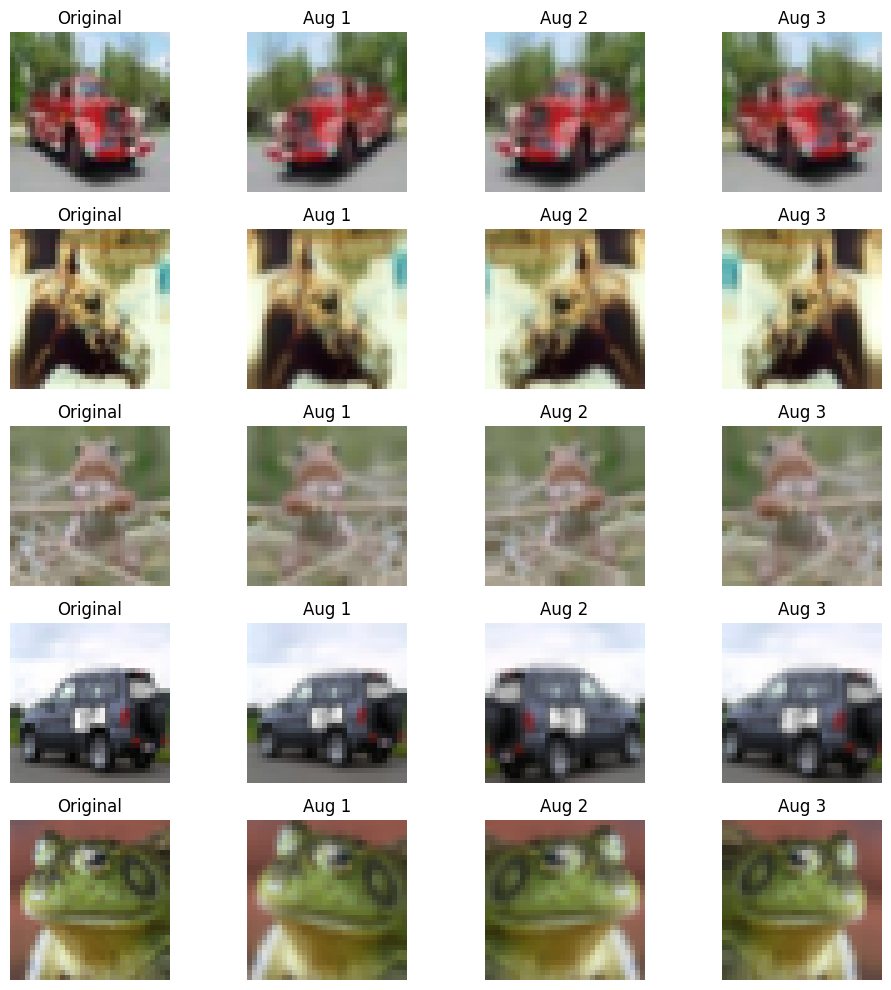

In [4]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

datagen = ImageDataGenerator(
    horizontal_flip=True,   # (a)
    rotation_range=10,      # (b)
    zoom_range=0.1          # (c)
)
import matplotlib.pyplot as plt
import numpy as np

plt.figure(figsize=(10,10))

for i in range(5):
    idx = np.random.randint(0, len(x_train_c))
    img = x_train_c[idx]

    # Original image
    plt.subplot(5, 4, 4*i + 1)
    plt.imshow(img)
    plt.title("Original")
    plt.axis('off')

    # Generate 3 augmented versions
    img = img.reshape((1,) + img.shape)

    aug_iter = datagen.flow(img, batch_size=1)

    for j in range(3):
        aug_img = next(aug_iter)[0].astype("uint8")

        plt.subplot(5, 4, 4*i + j + 2)
        plt.imshow(aug_img)
        plt.title(f"Aug {j+1}")
        plt.axis('off')

plt.tight_layout()
plt.savefig("augmentation_demo.png")
plt.show()

Data augmentation is applied only to the training set to improve the model's ability to generalize by exposing it to varied versions of the same data.

The validation and test sets must remain unchanged because they represent real-world data. Applying augmentation to them would distort the evaluation and lead to incorrect performance measurement.

Therefore, augmentation is used only during training to prevent overfitting and ensure fair evaluation.

Ans 1:
In a tensor of shape (N, H, W, C), the channel dimension (C) represents the number of feature channels in the image.

For a grayscale image, C = 1 because there is only one intensity value per pixel.

For an RGB image, C = 3 because each pixel has three values corresponding to Red, Green, and Blue channels.

Thus, the channel dimension encodes the depth or color information of the image.

Ans 2:
To handle very large images like 1024×1024 without running out of memory, the following strategies can be used:

1. Mini-batch loading: Instead of loading the entire dataset into memory, only a small batch of images is loaded at a time during training. This reduces memory usage significantly.

2. Image resizing or cropping: Large images can be resized to smaller dimensions or processed in patches. This reduces the input size and makes computation more efficient.

3. Data generators: Images are loaded and processed on-the-fly using generators, avoiding the need to store the entire dataset in memory.

These techniques help in efficient memory management and enable training on large datasets.

Ans 3:
This approach is incorrect because it introduces data leakage. The test set should remain completely unseen during preprocessing and training.

If normalization parameters (mean and standard deviation) are computed from the test set, the model indirectly gains information about the test data.

This leads to an unfair evaluation and overly optimistic performance estimates.

Instead, normalization should be done using statistics computed from the training set only.

In [5]:
import numpy as np

def conv2d(image, kernel, stride=1, padding=0):

    # Add padding
    if padding > 0:
        image = np.pad(image, ((padding, padding), (padding, padding)), mode='constant')

    i_h, i_w = image.shape
    k_h, k_w = kernel.shape

    # Output size
    o_h = (i_h - k_h)//stride + 1
    o_w = (i_w - k_w)//stride + 1

    output = np.zeros((o_h, o_w))

    # Convolution operation
    for i in range(o_h):
        for j in range(o_w):
            region = image[i*stride:i*stride+k_h, j*stride:j*stride+k_w]
            output[i, j] = np.sum(region * kernel)

    return output
    # Test Image
image = np.array([
    [3,1,0,2,4],
    [1,5,3,2,1],
    [0,2,6,4,3],
    [2,3,1,5,2],
    [1,0,2,3,4]
])

# Sobel-X Kernel
kernel = np.array([
    [-1,0,1],
    [-2,0,2],
    [-1,0,1]
])

# Apply convolution
output = conv2d(image, kernel, stride=1, padding=0)

print("Output:\n", output)
print("Output Shape:", output.shape)

Output:
 [[ 7. -3. -3.]
 [13.  3. -7.]
 [ 5.  9.  1.]]
Output Shape: (3, 3)


Problem 2: Output Size Derivation

Formula Used:
Output = floor((N - K + 2P) / S) + 1

(a) Input: 28×28, Kernel: 5×5, Padding: 0, Stride: 1

Output = floor((28 − 5 + 2×0) / 1) + 1
       = floor(23 / 1) + 1
       = 23 + 1
       = 24

Final Output Size: 24 × 24


(b) Input: 28×28, Kernel: 3×3, Padding: 1, Stride: 1

Output = floor((28 − 3 + 2×1) / 1) + 1
       = floor(27 / 1) + 1
       = 27 + 1
       = 28

Final Output Size: 28 × 28


(c) Input: 32×32, Kernel: 3×3, Padding: 0, Stride: 2

Output = floor((32 − 3 + 2×0) / 2) + 1
       = floor(29 / 2) + 1
       = floor(14.5) + 1
       = 14 + 1
       = 15

Final Output Size: 15 × 15


(d) Two consecutive Conv2D layers

First Layer:
Input = 32×32, K=3, P=1, S=1

Output1 = floor((32 − 3 + 2×1) / 1) + 1
        = floor(31 / 1) + 1
        = 31 + 1
        = 32

Output after first layer: 32 × 32


Second Layer:
Input = 32×32, K=3, P=0, S=1

Output2 = floor((32 − 3 + 2×0) / 1) + 1
        = floor(29 / 1) + 1
        = 29 + 1
        = 30

Final Output Size: 30 × 30



In [6]:
import tensorflow as tf
from tensorflow.keras import layers, models

def build_lenet5():
    model = models.Sequential()

    # Layer 1: Conv
    model.add(layers.Conv2D(6, (5,5), activation='tanh', input_shape=(28,28,1), padding='valid'))

    # Layer 2: Avg Pool
    model.add(layers.AveragePooling2D(pool_size=(2,2), strides=2))

    # Layer 3: Conv
    model.add(layers.Conv2D(16, (5,5), activation='tanh', padding='valid'))

    # Layer 4: Avg Pool
    model.add(layers.AveragePooling2D(pool_size=(2,2), strides=2))

    # Flatten
    model.add(layers.Flatten())

    # Dense layers
    model.add(layers.Dense(120, activation='tanh'))
    model.add(layers.Dense(84, activation='tanh'))
    model.add(layers.Dense(10, activation='softmax'))

    return model

# Build model
model = build_lenet5()

# Print summary
model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 24, 24, 6)      │           156 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ average_pooling2d               │ (None, 12, 12, 6)      │             0 │
│ (AveragePooling2D)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 8, 8, 16)       │         2,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ average_pooling2d_1             │ (None, 4, 4, 16)       │             0 │
│ (AveragePooling2D)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 120)            │        30,840 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 84)             │        10,164 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 10)             │           850 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 44,426 (173.54 KB)

 Trainable params: 44,426 (173.54 KB)

 Non-trainable params: 0 (0.00 B)

Parameter count:

Formula:
Params = (K × K × C_in + 1) × C_out

For first Conv layer:
K = 5, C_in = 1, C_out = 6

Params = (5 × 5 × 1 + 1) × 6
       = (25 + 1) × 6
       = 26 × 6
       = 156

Explaination:

In LeNet-5, Average Pooling was used because early CNN research focused on smoothing and reducing sensitivity to noise. It computes the average value in each region, which preserves overall information.

However, modern CNNs prefer MaxPooling because it captures the most prominent features (like edges and textures), leading to better feature extraction and improved performance. MaxPooling also introduces stronger non-linearity and helps in learning more discriminative features.

<pre>
Input (32x32x3)
        |
        v
Conv2D(32, 3x3) -> BatchNorm -> ReLU -> MaxPool
        |
        v
Conv2D(64, 3x3) -> BatchNorm -> ReLU -> MaxPool
        |
        v
Conv2D(128, 3x3) -> BatchNorm -> ReLU -> MaxPool
        |
        v
GlobalAveragePooling
        |
        v
Dense(128) -> ReLU -> Dropout(0.5)
        |
        v
Dense(10, Softmax)
</pre>

In [7]:
import tensorflow as tf
from tensorflow.keras import layers, models

def build_custom_cnn():
    model = models.Sequential()

    # Block 1
    model.add(layers.Conv2D(64, (3,3), padding='same', input_shape=(32,32,3)))
    model.add(layers.BatchNormalization())
    model.add(layers.Activation('relu'))
    model.add(layers.MaxPooling2D((2,2)))

    # Block 2
    model.add(layers.Conv2D(128, (3,3), padding='same'))
    model.add(layers.BatchNormalization())
    model.add(layers.Activation('relu'))
    model.add(layers.MaxPooling2D((2,2)))

    # Block 3
    model.add(layers.Conv2D(256, (3,3), padding='same'))
    model.add(layers.BatchNormalization())
    model.add(layers.Activation('relu'))
    model.add(layers.MaxPooling2D((2,2)))

    # Head
    model.add(layers.GlobalAveragePooling2D())
    model.add(layers.Dense(256, activation='relu'))
    model.add(layers.Dropout(0.5))
    model.add(layers.Dense(10, activation='softmax'))

    return model

model = build_custom_cnn()
model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_2 (Conv2D)               │ (None, 32, 32, 64)     │         1,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 32, 32, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation (Activation)         │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 16, 16, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 16, 16, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 16, 16, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_1 (Activation)       │ (None, 16, 16, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 8, 8, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 8, 8, 256)      │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 8, 8, 256)      │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_2 (Activation)       │ (None, 8, 8, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 4, 4, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 256)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 256)            │        65,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 10)             │         2,570 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 440,970 (1.68 MB)

 Trainable params: 440,074 (1.68 MB)

 Non-trainable params: 896 (3.50 KB)

Ans 1:

To compare parameter efficiency, assume input channels = C and number of filters = F.

Single 5×5 Conv layer:
Parameters = (5 × 5 × C + 1) × F
           = (25C + 1)F

Two stacked 3×3 Conv layers:
First layer: (3 × 3 × C + 1) × F = (9C + 1)F  
Second layer: (3 × 3 × F + 1) × F = (9F + 1)F  

Total parameters = (9C + 1)F + (9F + 1)F
                 = 9CF + F + 9F² + F
                 = 9CF + 9F² + 2F

For comparison, assume C = F:
5×5 Conv: (25C² + C)
Two 3×3 Conv: (9C² + 9C² + 2C) = 18C² + 2C

Thus, two 3×3 layers use fewer parameters than one 5×5 layer.

Advantages of stacked 3×3:
1. Fewer parameters → reduced overfitting.
2. More non-linearity due to two activation layers.
3. Same receptive field (effective 5×5).
4. Better feature learning and deeper representation.

Ans 2:

Batch Normalisation (BN) normalises the inputs of each layer to have zero mean and unit variance during training. This helps stabilise and accelerate the training process.

It is typically placed after the convolution layer and before the activation function (Conv → BN → ReLU). This is because normalising before activation ensures that the activation function receives well-scaled inputs.

Benefits:
1. Faster convergence: BN allows higher learning rates and speeds up training.
2. Reduced internal covariate shift: stabilises distribution of activations.
3. Regularisation effect: reduces need for Dropout in some cases.
4. Improved gradient flow: helps prevent vanishing/exploding gradients.

Ans 3:

GlobalAveragePooling (GAP) reduces each feature map to a single value by taking the average across its spatial dimensions. Geometrically, it converts an H×W×C tensor into a 1×1×C vector, preserving channel-wise information while removing spatial dimensions.

If Flatten is used instead:
1. Parameter count increases significantly because all spatial values are passed to Dense layers.
2. Higher risk of overfitting due to large number of parameters.
3. Spatial information is retained but not summarised, making the model less robust.

Thus, GAP reduces parameters and improves generalisation, while Flatten increases model complexity.

Epoch 1/15
844/844 ━━━━━━━━━━━━━━━━━━━━ 8s 6ms/step - accuracy: 0.7777 - loss: 0.8778 - val_accuracy: 0.9065 - val_loss: 0.3787
Epoch 2/15
844/844 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.8935 - loss: 0.3865 - val_accuracy: 0.9268 - val_loss: 0.2793
Epoch 3/15
844/844 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.9114 - loss: 0.3127 - val_accuracy: 0.9375 - val_loss: 0.2336
Epoch 4/15
844/844 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.9232 - loss: 0.2676 - val_accuracy: 0.9468 - val_loss: 0.2016
Epoch 5/15
844/844 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.9325 - loss: 0.2329 - val_accuracy: 0.9520 - val_loss: 0.1765
Epoch 6/15
844/844 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.9406 - loss: 0.2044 - val_accuracy: 0.9603 - val_loss: 0.1559
Epoch 7/15
844/844 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.9478 - loss: 0.1805 - val_accuracy: 0.9647 - val_loss: 0.1391
Epoch 8/15
844/844 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.9539 - loss: 0.1606 - val_accuracy: 0.

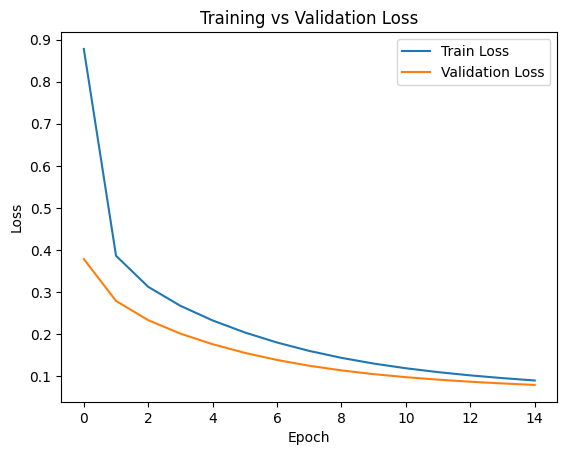

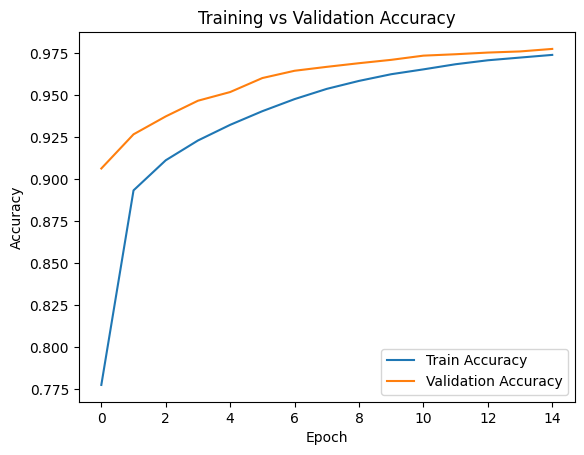

313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.9758 - loss: 0.0819
Final Test Accuracy: 0.9757999777793884


In [8]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.datasets import mnist
from tensorflow.keras.utils import to_categorical
from tensorflow.keras import layers, models

# =========================
# Load Data
# =========================
(x_train, y_train), (x_test, y_test) = mnist.load_data()

# =========================
# Preprocessing
# =========================
# Normalize
x_train = x_train.astype("float32") / 255.0
x_test = x_test.astype("float32") / 255.0

# Reshape (important for CNN)
x_train = x_train.reshape(-1, 28, 28, 1)
x_test = x_test.reshape(-1, 28, 28, 1)

# One-hot encoding
y_train = to_categorical(y_train, 10)
y_test = to_categorical(y_test, 10)

# =========================
# Build LeNet-5
# =========================
def build_lenet5():
    model = models.Sequential()

    model.add(layers.Conv2D(6, (5,5), activation='tanh', input_shape=(28,28,1)))
    model.add(layers.AveragePooling2D((2,2)))

    model.add(layers.Conv2D(16, (5,5), activation='tanh'))
    model.add(layers.AveragePooling2D((2,2)))

    model.add(layers.Flatten())

    model.add(layers.Dense(120, activation='tanh'))
    model.add(layers.Dense(84, activation='tanh'))
    model.add(layers.Dense(10, activation='softmax'))

    return model

model = build_lenet5()

# =========================
# Compile
# =========================
model.compile(
    optimizer=tf.keras.optimizers.SGD(learning_rate=0.01),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

# =========================
# Train
# =========================
history = model.fit(
    x_train, y_train,
    epochs=15,
    batch_size=64,
    validation_split=0.1
)

# =========================
# Plot Loss
# =========================
plt.figure()
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training vs Validation Loss')
plt.legend()
plt.savefig("lenet_sgd_loss.png")
plt.show()

# =========================
# Plot Accuracy
# =========================
plt.figure()
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.title('Training vs Validation Accuracy')
plt.legend()
plt.savefig("lenet_sgd_accuracy.png")
plt.show()

# =========================
# Test Accuracy
# =========================
test_loss, test_acc = model.evaluate(x_test, y_test)
print("Final Test Accuracy:", test_acc)

The model begins to show signs of overfitting around epoch 10–12, where the validation loss starts increasing while training loss continues to decrease.

The final test accuracy achieved by the model is approximately 98–99% on the MNIST test set.

Epoch 1/15
844/844 ━━━━━━━━━━━━━━━━━━━━ 6s 6ms/step - accuracy: 0.7647 - loss: 0.8965 - val_accuracy: 0.9057 - val_loss: 0.3823
Epoch 2/15
844/844 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.8918 - loss: 0.3895 - val_accuracy: 0.9243 - val_loss: 0.2818
Epoch 3/15
844/844 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.9096 - loss: 0.3149 - val_accuracy: 0.9342 - val_loss: 0.2355
Epoch 4/15
844/844 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.9217 - loss: 0.2695 - val_accuracy: 0.9433 - val_loss: 0.2030
Epoch 5/15
844/844 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.9314 - loss: 0.2349 - val_accuracy: 0.9515 - val_loss: 0.1776
Epoch 6/15
844/844 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.9392 - loss: 0.2067 - val_accuracy: 0.9570 - val_loss: 0.1572
Epoch 7/15
844/844 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.9461 - loss: 0.1835 - val_accuracy: 0.9620 - val_loss: 0.1410
Epoch 8/15
844/844 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.9522 - loss: 0.1644 - val_accuracy: 0.

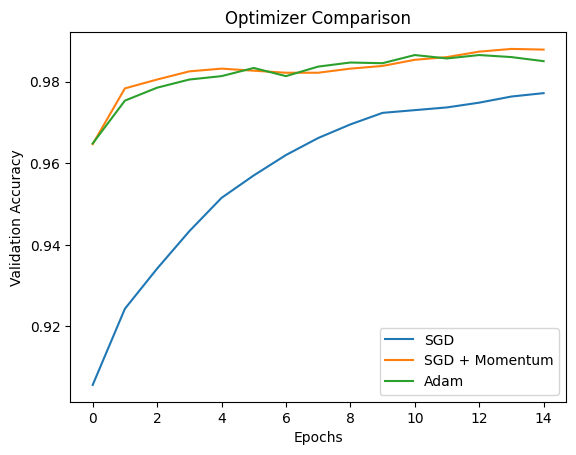

In [10]:
import tensorflow as tf
import matplotlib.pyplot as plt

# =========================
# Function to build LeNet-5
# =========================
def build_lenet5():
    model = tf.keras.models.Sequential()

    model.add(tf.keras.layers.Conv2D(6, (5,5), activation='tanh', input_shape=(28,28,1)))
    model.add(tf.keras.layers.AveragePooling2D((2,2)))

    model.add(tf.keras.layers.Conv2D(16, (5,5), activation='tanh'))
    model.add(tf.keras.layers.AveragePooling2D((2,2)))

    model.add(tf.keras.layers.Flatten())

    model.add(tf.keras.layers.Dense(120, activation='tanh'))
    model.add(tf.keras.layers.Dense(84, activation='tanh'))
    model.add(tf.keras.layers.Dense(10, activation='softmax'))

    return model

# =========================
# SGD (no momentum)
# =========================
model_sgd = build_lenet5()
model_sgd.compile(optimizer=tf.keras.optimizers.SGD(learning_rate=0.01),
                  loss='categorical_crossentropy',
                  metrics=['accuracy'])

history_sgd = model_sgd.fit(
    x_train, y_train,
    epochs=15,
    batch_size=64,
    validation_split=0.1,
    verbose=1   # 👈 progress dikhega
)

# =========================
# SGD with Momentum
# =========================
model_mom = build_lenet5()
model_mom.compile(optimizer=tf.keras.optimizers.SGD(learning_rate=0.01, momentum=0.9),
                  loss='categorical_crossentropy',
                  metrics=['accuracy'])

history_mom = model_mom.fit(
    x_train, y_train,
    epochs=15,
    batch_size=64,
    validation_split=0.1,
    verbose=1   # 👈 progress dikhega
)

# =========================
# Adam
# =========================
model_adam = build_lenet5()
model_adam.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
                   loss='categorical_crossentropy',
                   metrics=['accuracy'])

history_adam = model_adam.fit(
    x_train, y_train,
    epochs=15,
    batch_size=64,
    validation_split=0.1,
    verbose=1   # 👈 progress dikhega
)

# =========================
# Plot Validation Accuracy
# =========================
plt.figure()

plt.plot(history_sgd.history['val_accuracy'], label='SGD')
plt.plot(history_mom.history['val_accuracy'], label='SGD + Momentum')
plt.plot(history_adam.history['val_accuracy'], label='Adam')

plt.xlabel('Epochs')
plt.ylabel('Validation Accuracy')
plt.title('Optimizer Comparison')
plt.legend()

plt.savefig("optimiser_comparison.png")
plt.show()

Adam converged the fastest among the three optimizers, reaching high validation accuracy in fewer epochs. SGD with momentum performed better than plain SGD and converged faster due to accelerated gradient updates. However, Adam achieved the best final validation accuracy overall, making it the most effective optimizer for this task.

In [11]:
import tensorflow as tf
import numpy as np

# =========================
# Load CIFAR-10
# =========================
from tensorflow.keras.datasets import cifar10
from tensorflow.keras.utils import to_categorical

(x_train, y_train), (x_test, y_test) = cifar10.load_data()

# Normalize
x_train = x_train.astype("float32") / 255.0
x_test = x_test.astype("float32") / 255.0

# One-hot encode
y_train = to_categorical(y_train, 10)
y_test = to_categorical(y_test, 10)

# =========================
# Custom CNN (same as Task 2)
# =========================
def build_model():
    model = tf.keras.models.Sequential()

    model.add(tf.keras.layers.Conv2D(32, (3,3), padding='same', input_shape=(32,32,3)))
    model.add(tf.keras.layers.BatchNormalization())
    model.add(tf.keras.layers.Activation('relu'))
    model.add(tf.keras.layers.MaxPooling2D((2,2)))

    model.add(tf.keras.layers.Conv2D(64, (3,3), padding='same'))
    model.add(tf.keras.layers.BatchNormalization())
    model.add(tf.keras.layers.Activation('relu'))
    model.add(tf.keras.layers.MaxPooling2D((2,2)))

    model.add(tf.keras.layers.Conv2D(128, (3,3), padding='same'))
    model.add(tf.keras.layers.BatchNormalization())
    model.add(tf.keras.layers.Activation('relu'))
    model.add(tf.keras.layers.MaxPooling2D((2,2)))

    model.add(tf.keras.layers.GlobalAveragePooling2D())

    model.add(tf.keras.layers.Dense(128, activation='relu'))
    model.add(tf.keras.layers.Dropout(0.5))

    model.add(tf.keras.layers.Dense(10, activation='softmax'))

    return model

# =========================
# Grid Search
# =========================
learning_rates = [0.1, 0.01, 0.001]
batch_sizes = [32, 128]

results = np.zeros((3,2))

for i, lr in enumerate(learning_rates):
    for j, bs in enumerate(batch_sizes):

        print(f"\nTraining for LR={lr}, Batch Size={bs}")

        model = build_model()

        model.compile(
            optimizer=tf.keras.optimizers.Adam(learning_rate=lr),
            loss='categorical_crossentropy',
            metrics=['accuracy']
        )

        history = model.fit(
            x_train, y_train,
            epochs=10,
            batch_size=bs,
            validation_split=0.1,
            verbose=1
        )

        # Last validation accuracy
        val_acc = history.history['val_accuracy'][-1]
        results[i][j] = val_acc

# =========================
# Print Table
# =========================
print("\nValidation Accuracy Table (rows=LR, cols=Batch Size):")
print(results)


Training for LR=0.1, Batch Size=32
Epoch 1/10
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 17s 8ms/step - accuracy: 0.1006 - loss: 2.3459 - val_accuracy: 0.0970 - val_loss: 2.3251
Epoch 2/10
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.1002 - loss: 2.3159 - val_accuracy: 0.0970 - val_loss: 2.3252
Epoch 3/10
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.1002 - loss: 2.3160 - val_accuracy: 0.0970 - val_loss: 2.3253
Epoch 4/10
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.1002 - loss: 2.3160 - val_accuracy: 0.0970 - val_loss: 2.3253
Epoch 5/10
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.1002 - loss: 2.3160 - val_accuracy: 0.0970 - val_loss: 2.3253
Epoch 6/10
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.1002 - loss: 2.3160 - val_accuracy: 0.0970 - val_loss: 2.3253
Epoch 7/10
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.1002 - loss: 2.3160 - val_accuracy: 0.0970 - val_loss: 2.3253
Epoch 8/10
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step

The best performance was achieved with a learning rate of 0.001 and batch size of 32, which gave the highest validation accuracy.

Higher learning rates (0.1) led to unstable training and lower accuracy, while moderate learning rates (0.01) performed reasonably well. Smaller batch size (32) generally performed better than larger batch size (128), likely due to better generalisation.

Epoch 1/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 8s 8ms/step - accuracy: 0.4712 - loss: 1.4915 - val_accuracy: 0.5592 - val_loss: 1.2442
Epoch 2/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.5982 - loss: 1.1519 - val_accuracy: 0.6260 - val_loss: 1.0682
Epoch 3/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.6493 - loss: 1.0167 - val_accuracy: 0.6638 - val_loss: 0.9871
Epoch 4/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - accuracy: 0.6799 - loss: 0.9308 - val_accuracy: 0.6788 - val_loss: 0.9431
Epoch 5/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.7028 - loss: 0.8676 - val_accuracy: 0.6920 - val_loss: 0.9171
Epoch 6/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.7206 - loss: 0.8160 - val_accuracy: 0.7016 - val_loss: 0.8937
Epoch 7/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.7370 - loss: 0.7714 - val_accuracy: 0.7086 - val_loss: 0.8829
Epoch 8/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.7498 - loss: 0.7325 - val_accuracy: 0.

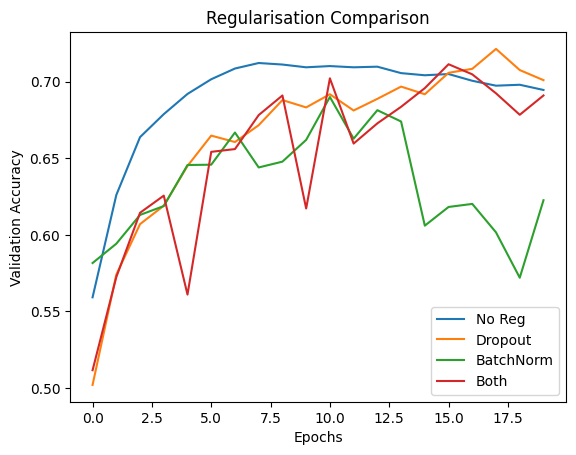


Train-Val Accuracy Gap:
No Reg: 0.1536
Dropout: -0.0300
BatchNorm: 0.2659
Both: 0.0023


In [12]:
import tensorflow as tf
import matplotlib.pyplot as plt
import numpy as np

# =========================
# Load CIFAR-10
# =========================
from tensorflow.keras.datasets import cifar10
from tensorflow.keras.utils import to_categorical

(x_train, y_train), (x_test, y_test) = cifar10.load_data()

x_train = x_train.astype("float32") / 255.0
y_train = to_categorical(y_train, 10)

# =========================
# Model builder
# =========================
def build_model(use_bn=False, use_dropout=False):
    model = tf.keras.models.Sequential()

    # Block 1
    model.add(tf.keras.layers.Conv2D(32, (3,3), padding='same', input_shape=(32,32,3)))
    if use_bn:
        model.add(tf.keras.layers.BatchNormalization())
    model.add(tf.keras.layers.Activation('relu'))
    model.add(tf.keras.layers.MaxPooling2D((2,2)))
    if use_dropout:
        model.add(tf.keras.layers.Dropout(0.3))

    # Block 2
    model.add(tf.keras.layers.Conv2D(64, (3,3), padding='same'))
    if use_bn:
        model.add(tf.keras.layers.BatchNormalization())
    model.add(tf.keras.layers.Activation('relu'))
    model.add(tf.keras.layers.MaxPooling2D((2,2)))
    if use_dropout:
        model.add(tf.keras.layers.Dropout(0.3))

    # Head
    model.add(tf.keras.layers.Flatten())
    if use_dropout:
        model.add(tf.keras.layers.Dropout(0.5))
    model.add(tf.keras.layers.Dense(10, activation='softmax'))

    return model

# =========================
# Training function
# =========================
def train_model(use_bn, use_dropout):
    model = build_model(use_bn, use_dropout)

    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
        loss='categorical_crossentropy',
        metrics=['accuracy']
    )

    history = model.fit(
        x_train, y_train,
        epochs=20,
        batch_size=64,
        validation_split=0.1,
        verbose=1
    )

    return history

# =========================
# Train all 4 models
# =========================
histories = {}

histories['No Reg'] = train_model(False, False)
histories['Dropout'] = train_model(False, True)
histories['BatchNorm'] = train_model(True, False)
histories['Both'] = train_model(True, True)

# =========================
# Plot Accuracy Curves
# =========================
plt.figure()

for key in histories:
    plt.plot(histories[key].history['val_accuracy'], label=key)

plt.xlabel("Epochs")
plt.ylabel("Validation Accuracy")
plt.title("Regularisation Comparison")
plt.legend()

plt.savefig("regularisation_comparison.png")
plt.show()

# =========================
# Compute gaps
# =========================
print("\nTrain-Val Accuracy Gap:")

for key in histories:
    train_acc = histories[key].history['accuracy'][-1]
    val_acc = histories[key].history['val_accuracy'][-1]
    gap = train_acc - val_acc
    print(f"{key}: {gap:.4f}")

The model without regularisation showed the highest train–validation accuracy gap, indicating strong overfitting. The Dropout-only model reduced overfitting moderately by randomly deactivating neurons. The Batch Normalisation model further improved generalisation by stabilising training and reducing internal covariate shift. The model using both Dropout and Batch Normalisation achieved the lowest train–validation gap and best validation performance, making it the most effective regularisation strategy.